In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Evaluation
from sklearn.metrics import silhouette_score

# Download NLP resources
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
# Load CSV file

df = pd.read_csv("raw_anonymized_data.csv")

# Display first rows

df.head()

,ID,cancer,diabetes,heart_disease,belly,ever_smoked,currently_smoke,smoke_often,smoke_rarely,never_smoked,...,DT_FIBER_INSOL,DT_FIBER_SOL,DT_PROT_ANIMAL,DT_PROT_VEGETABLE,DT_NITROGEN,PHYTIC_ACID,OXALIC_ACID,COUMESTROL,BIOCHANIN_A,FORMONONETIN
0,1003,Yes,No,No,Innie,Yes,Yes,Yes,No,No,...,7.38,1.25,75.46,16.00,14.89,365.70,318.11,0.0117,0.0658,0.00324
1,1053,No,Yes,Yes,Outie,Yes,Yes,No,Yes,No,...,9.11,3.37,59.41,18.25,12.51,434.98,112.66,0.0107,0.1390,0.00743
2,1006,Yes,Yes,Yes,Innie,No,No,No,No,Yes,...,11.56,4.74,61.49,28.46,14.45,606.43,213.41,0.0965,0.0519,0.00946
3,1166,No,No,No,Innie,No,No,No,No,Yes,...,26.34,10.85,28.71,44.59,12.15,1570.07,334.08,0.2830,0.0890,0.01260
4,1134,Yes,No,No,Innie,No,No,No,No,Yes,...,16.48,4.80,32.41,28.23,9.80,616.99,422.55,0.1630,0.0994,0.02070


In [3]:
# Dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Columns: 1093 entries, ID to FORMONONETIN
dtypes: float64(554), int64(513), str(26)
memory usage: 464.6 KB


In [4]:
# Check missing values

df.isnull().sum()

ID               0
cancer           0
diabetes         0
heart_disease    0
belly            0
                ..
PHYTIC_ACID      0
OXALIC_ACID      0
COUMESTROL       0
BIOCHANIN_A      0
FORMONONETIN     0
Length: 1093, dtype: int64

In [5]:
# Dataset shape

df.shape

(54, 1093)

In [6]:
# Find text columns

text_columns = df.select_dtypes(include=['object']).columns

text_columns

/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_78991/3645602333.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include=['object']).columns


Index(['cancer', 'diabetes', 'heart_disease', 'belly', 'ever_smoked',
       'currently_smoke', 'smoke_often', 'smoke_rarely', 'never_smoked',
       'quit_smoking', 'left_hand', 'right_hand', 'readingMath', 'mathReading',
       'favCable', 'unfavCable', 'neutralCable', 'noCrash', 'yesCrash',
       'uhCrash', 'rash', 'cat', 'dog', 'Dems', 'atheist', 'Jewish'],
      dtype='str')

In [7]:
# Replace missing text values

df[text_columns] = df[text_columns].fillna("")


# Combine all text columns into one column

df["combined_text"] = df[text_columns].apply(
    lambda x: " ".join(x),
    axis=1
)


df["combined_text"].head()

/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_78991/355433002.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["combined_text"] = df[text_columns].apply(


0    Yes No No Innie Yes Yes Yes No No No No Yes Ye...
1    No Yes Yes Outie Yes Yes No Yes No No No Yes N...
2    Yes Yes Yes Innie No No No No Yes No No Yes No...
3    No No No Innie No No No No Yes No No Yes No No...
4    Yes No No Innie No No No No Yes No No Yes No Y...
Name: combined_text, dtype: str

In [8]:
stop_words = set(stopwords.words("english"))


def clean_text(text):
    
    text = text.lower()
    
    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove stopwords
    words = text.split()
    
    words = [
        word for word in words 
        if word not in stop_words
    ]
    
    return " ".join(words)



df["clean_text"] = df["combined_text"].apply(clean_text)


df[["combined_text","clean_text"]].head()

/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_78991/1791025165.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["clean_text"] = df["combined_text"].apply(clean_text)


,combined_text,clean_text
0,Yes No No Innie Yes Yes Yes No No No No Yes Ye...,yes innie yes yes yes yes yes yes yes yes yes yes
1,No Yes Yes Outie Yes Yes No Yes No No No Yes N...,yes yes outie yes yes yes yes yes yes yes yes ...
2,Yes Yes Yes Innie No No No No Yes No No Yes No...,yes yes yes innie yes yes yes yes yes yes
3,No No No Innie No No No No Yes No No Yes No No...,innie yes yes yes yes yes yes
4,Yes No No Innie No No No No Yes No No Yes No Y...,yes innie yes yes yes yes yes yes yes


In [9]:
tfidf = TfidfVectorizer(
    max_features=1000
)


text_features = tfidf.fit_transform(
    df["clean_text"]
)


text_features.shape

(54, 3)

In [10]:
tfidf_df = pd.DataFrame(
    text_features.toarray(),
    columns=tfidf.get_feature_names_out()
)


tfidf_df.head()

,innie,outie,yes
0,0.099084,0.000000,0.995079
1,0.000000,0.258833,0.965922
2,0.120810,0.000000,0.992676
3,0.179584,0.000000,0.983743
4,0.135648,0.000000,0.990757


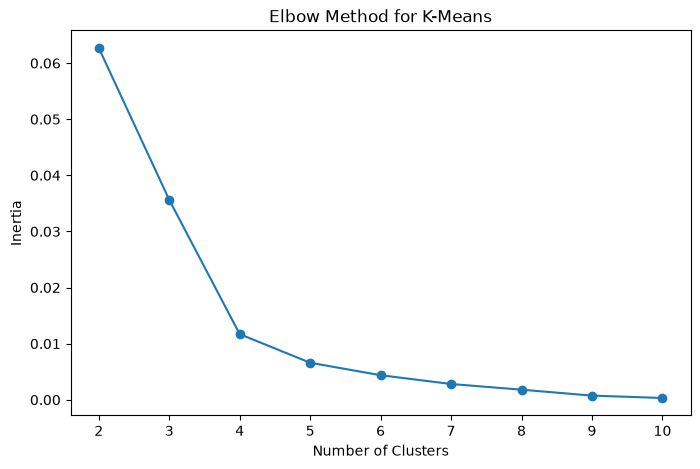

In [11]:
inertia = []


K = range(2,11)


for k in K:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(text_features)
    
    inertia.append(kmeans.inertia_)



plt.figure(figsize=(8,5))

plt.plot(
    K,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.title(
    "Elbow Method for K-Means"
)

plt.show()

In [12]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)


df["Cluster"] = kmeans.fit_predict(
    text_features
)


df.head()

/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_78991/590497536.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Cluster"] = kmeans.fit_predict(


,ID,cancer,diabetes,heart_disease,belly,ever_smoked,currently_smoke,smoke_often,smoke_rarely,never_smoked,...,DT_PROT_VEGETABLE,DT_NITROGEN,PHYTIC_ACID,OXALIC_ACID,COUMESTROL,BIOCHANIN_A,FORMONONETIN,combined_text,clean_text,Cluster
0,1003,Yes,No,No,Innie,Yes,Yes,Yes,No,No,...,16.00,14.89,365.70,318.11,0.0117,0.0658,0.00324,Yes No No Innie Yes Yes Yes No No No No Yes Ye...,yes innie yes yes yes yes yes yes yes yes yes yes,0
1,1053,No,Yes,Yes,Outie,Yes,Yes,No,Yes,No,...,18.25,12.51,434.98,112.66,0.0107,0.1390,0.00743,No Yes Yes Outie Yes Yes No Yes No No No Yes N...,yes yes outie yes yes yes yes yes yes yes yes ...,2
2,1006,Yes,Yes,Yes,Innie,No,No,No,No,Yes,...,28.46,14.45,606.43,213.41,0.0965,0.0519,0.00946,Yes Yes Yes Innie No No No No Yes No No Yes No...,yes yes yes innie yes yes yes yes yes yes,0
3,1166,No,No,No,Innie,No,No,No,No,Yes,...,44.59,12.15,1570.07,334.08,0.2830,0.0890,0.01260,No No No Innie No No No No Yes No No Yes No No...,innie yes yes yes yes yes yes,3
4,1134,Yes,No,No,Innie,No,No,No,No,Yes,...,28.23,9.80,616.99,422.55,0.1630,0.0994,0.02070,Yes No No Innie No No No No Yes No No Yes No Y...,yes innie yes yes yes yes yes yes yes,4


In [13]:
df["Cluster"].value_counts()

Cluster
0    29
4    13
3     7
1     3
2     2
Name: count, dtype: int64

In [14]:
score = silhouette_score(
    text_features,
    df["Cluster"]
)


print(
    "Silhouette Score:",
    score
)

Silhouette Score: 0.6752786379261009


In [15]:
pca = PCA(
    n_components=2
)


reduced_features = pca.fit_transform(
    text_features.toarray()
)


pca_df = pd.DataFrame(
    reduced_features,
    columns=[
        "PCA1",
        "PCA2"
    ]
)


pca_df["Cluster"] = df["Cluster"]


pca_df.head()

,PCA1,PCA2,Cluster
0,-0.024584,-0.029938,0
1,0.253742,-0.034229,2
2,-0.031818,-0.009361,0
3,-0.051013,0.046883,3
4,-0.036716,0.004759,4


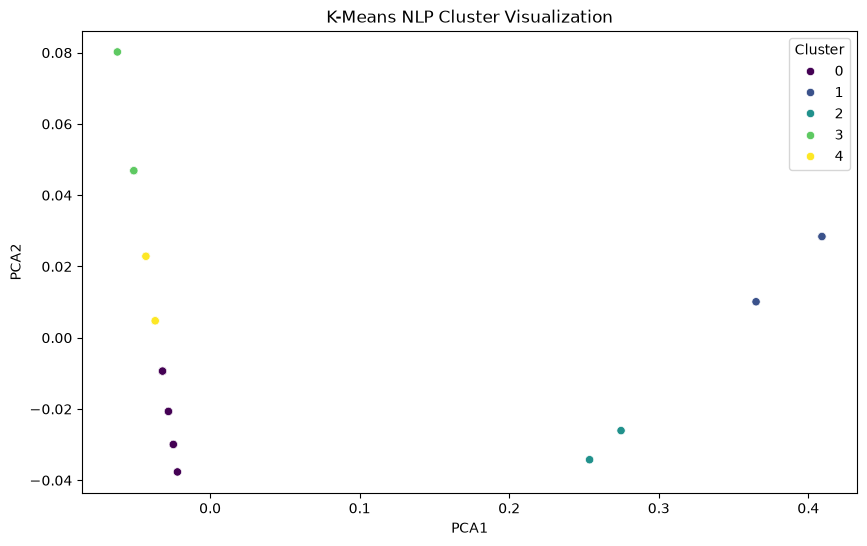

In [16]:
plt.figure(figsize=(10,6))


sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="viridis"
)


plt.title(
    "K-Means NLP Cluster Visualization"
)


plt.show()

In [17]:
terms = tfidf.get_feature_names_out()


for cluster in range(5):

    center = kmeans.cluster_centers_[cluster]

    top_words = center.argsort()[-10:]

    print(
        f"\nCluster {cluster}"
    )

    print(
        terms[top_words]
    )


Cluster 0
['outie' 'innie' 'yes']

Cluster 1
['innie' 'outie' 'yes']

Cluster 2
['innie' 'outie' 'yes']

Cluster 3
['outie' 'innie' 'yes']

Cluster 4
['outie' 'innie' 'yes']


In [18]:
df.to_csv(
    "raw_anonymized_data_kmeans_clusters.csv",
    index=False
)